# EDA ④ 방위사업청 국외 조달계획 품목 단위 (OpenAPI `15158418`) — 적용장비 · 군 축

산출물 4 「전처리 및 EDA 보고서」 중 국외 조달계획 편

| 항목 | 내용 |
|---|---|
| 데이터 | RDS `clean_dapa_overseas_plan_api` 13,615행(소요연도 2016~2026) — 재고번호(NSN) · 군 · 적용장비명 · 수량 |
| 쿼리 | `db/query_eda2_2026-09-23.sql`의 블록 [B1]~[B8] — 화면(②·⑤)과 같은 SQL |
| 분모 | **군급 판별 가능 13,017행**(군급 없는 379행 · 임시 번호 9999 219행 제외). 13자리 숫자 NSN만 쓰는 9,955는 영숫자 NSN 3,266행(전자 440행)을 빠뜨려 쓰지 않는다 |

**해석 경계**: 이 자료에는 **공급 국가가 없다** — 공급국을 추정하지 않는다. 금액은 통화가 확인되지 않아 **건수만** 쓴다. 관세청 HS 품목군과 **결합하지 않는다**. 적용장비명은 「이 품목이 이 장비용으로 계획됐다」까지이며 부품표(BOM)가 아니다. 통계 검정 없이 **세고 · 나누고 · 순위**만 본다.

목차: 1 단계 보고 → 2 군별 전자 군급 비중 → 3 적용장비 상위 20 → 4 군급 × 적용장비 → 5 소요연도별 구성 → 6 국외조달 vs 국산화 → 7 (부록) 계약방법 구성 → 8 국방표준 연결률 → 9 요약 · 한계

In [1]:
import sys, re, platform, warnings
from decimal import Decimal
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "scripts"))
import pymysql, dbconf

plt.rcParams["font.family"] = {"Darwin": "AppleGothic", "Windows": "Malgun Gothic"}.get(platform.system(), "NanumGothic")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30, "display.width", 180)

# 색: 한 가지 색(파랑)의 농도 + 회색. 위험·정상 뜻의 빨강·초록은 쓰지 않는다.
BLUE, BLUE2, BLUE3, BLUE4 = "#1f4e99", "#2a6fdb", "#7fa8e8", "#c9daf5"
GRAY = "#b8c0cc"

# 쿼리는 db/query_eda2_2026-09-23.sql 한 곳에만 둔다 — 화면(Streamlit)과 같은 SQL을 쓰기 위해서다.
SQL_FILE = ROOT / "db" / "query_eda2_2026-09-23.sql"
Q = {}
for block in re.split(r"\n(?=-- \[)", SQL_FILE.read_text(encoding="utf-8")):
    m = re.match(r"-- \[(\w+)\]", block)
    if m:
        Q[m.group(1)] = "\n".join(l for l in block.splitlines() if not l.startswith("--")).strip().rstrip(";")

conn = pymysql.connect(**dbconf.pymysql_kwargs("etl", read_timeout=180))

def q(key):
    """쿼리 블록 하나를 실행해 DataFrame으로. Decimal은 float로 바꾼다."""
    with conn.cursor() as cur:
        cur.execute(Q[key])
        df = pd.DataFrame(cur.fetchall(), columns=[d[0] for d in cur.description])
    for c in df.columns:
        if df[c].map(lambda v: isinstance(v, Decimal)).any():
            df[c] = df[c].astype(float)
    return df

print("쿼리 블록:", ", ".join(sorted(Q)))

쿼리 블록: A1, A10, A2, A3, A4, A5, A6, A7, A8, A9, B1, B2, B3, B4, B5, B6, B7, B8


## 1. 단계 보고 [B1]

전체 → 군급 판별 → 임시 번호(9999) 제외 → 전자 군급(FSG 58 통신 · 탐지 / 59 전기 · 전자 구성품 / 60 광섬유).

In [2]:
b1 = q("B1").iloc[0]
steps = pd.DataFrame({
    "단계": ["① 전체 품목 행", "② 군급(FSG) 판별 가능", "③ 임시 번호(9999) 제외 = 분모", "④ 전자 군급(58·59·60)"],
    "행 수": [b1.s1_all, b1.s2_fsg_identified, b1.s3_fsg_valid, b1.s4_elec],
    "빠진 이유": ["", f"자리표시 재고번호 {int(b1.x_placeholder):,} 등 군급 없음 {int(b1.s1_all - b1.s2_fsg_identified):,}", f"임시 배정 9999 {int(b1.x_temp_9999):,}", "비전자 군급"],
}).astype({"행 수": int})
print(f"참고: 영숫자 13자리 NSN {int(b1.note_alnum_nsn):,}행은 군급이 정상 판별되므로 분모에 포함")
steps

참고: 영숫자 13자리 NSN 3,266행은 군급이 정상 판별되므로 분모에 포함


,단계,행 수,빠진 이유
0,① 전체 품목 행,13615,
1,② 군급(FSG) 판별 가능,13236,자리표시 재고번호 347 등 군급 없음 379
2,③ 임시 번호(9999) 제외 = 분모,13017,임시 배정 9999 219
3,④ 전자 군급(58·59·60),2267,비전자 군급


## 2. 군별 전자 군급 비중 [B2]

분모는 군마다 군급 판별 가능 행. 국직(2행)은 너무 작아 그림에서 뺀다.

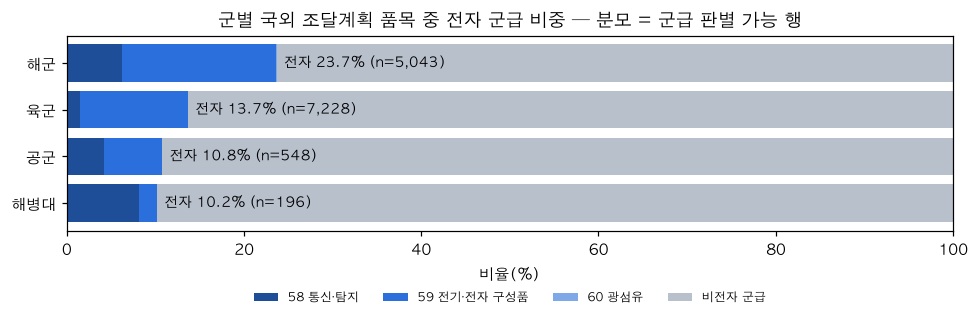

,army_std,n_valid,fsg58,fsg59,fsg60,elec_pct
0,육군,7228.0,107.0,880.0,6.0,13.7
1,해군,5043.0,315.0,875.0,5.0,23.7
2,공군,548.0,23.0,36.0,0.0,10.8
3,해병대,196.0,16.0,4.0,0.0,10.2


In [3]:
b2 = q("B2")
b2 = b2[b2.n_valid >= 100].copy()
b2["비전자"] = b2.n_valid - b2[["fsg58", "fsg59", "fsg60"]].sum(axis=1)
pct = b2.set_index("army_std")[["fsg58", "fsg59", "fsg60", "비전자"]].div(b2.set_index("army_std").n_valid, axis=0) * 100
pct = pct.loc[pct[["fsg58", "fsg59", "fsg60"]].sum(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(9, 3.2))
left = np.zeros(len(pct))
for col, color, lab in [("fsg58", BLUE, "58 통신·탐지"), ("fsg59", BLUE2, "59 전기·전자 구성품"), ("fsg60", BLUE3, "60 광섬유"), ("비전자", GRAY, "비전자 군급")]:
    ax.barh(pct.index, pct[col], left=left, color=color, label=lab); left += pct[col].values
for i, (a, r) in enumerate(b2.set_index("army_std").loc[pct.index].iterrows()):
    ax.text(r.elec_pct + 0.8, i, f"전자 {r.elec_pct:.1f}% (n={int(r.n_valid):,})", va="center", fontsize=9)
ax.set(xlim=(0, 100), xlabel="비율(%)", title="군별 국외 조달계획 품목 중 전자 군급 비중 — 분모 = 군급 판별 가능 행")
ax.legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=False)
plt.tight_layout(); plt.show()
b2[["army_std", "n_valid", "fsg58", "fsg59", "fsg60", "elec_pct"]]

## 3. 적용장비 상위 20 [B3]

적용장비명이 비어 있는 2,018행(14.8%)은 채우지 않고 「미상」으로 따로 센다.

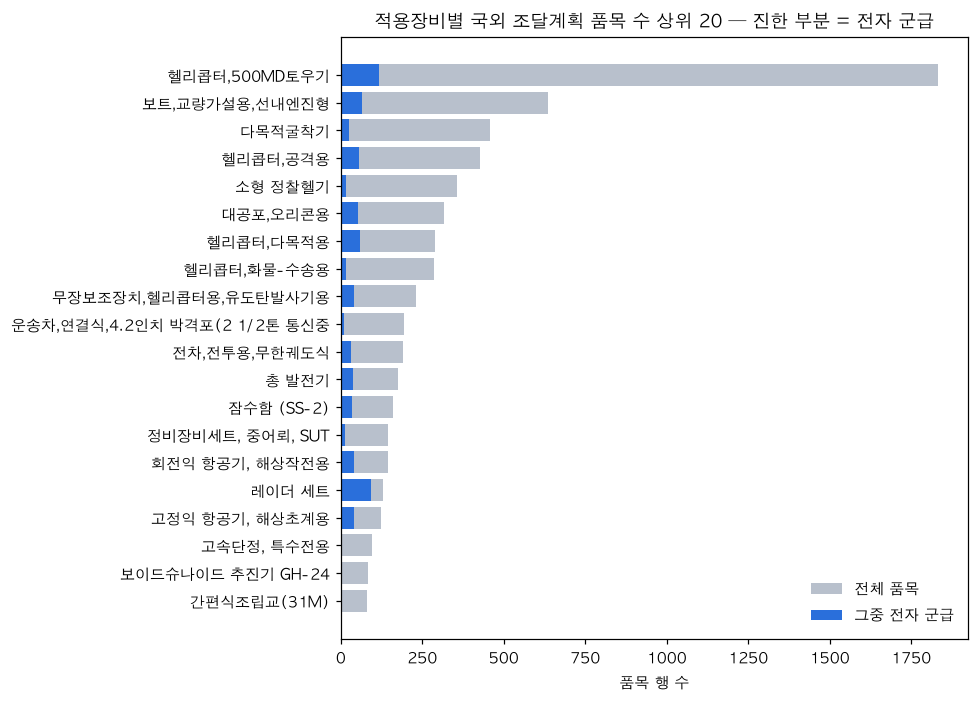

미상(적용장비명 결측): 2,018행, 그중 전자 군급 215행


,equipment,n_items,n_elec,전자_비율
1,"헬리콥터,500MD토우기",1833,119.0,6.5
2,"보트,교량가설용,선내엔진형",635,66.0,10.4
3,다목적굴착기,459,27.0,5.9
4,"헬리콥터,공격용",428,56.0,13.1
5,소형 정찰헬기,358,15.0,4.2
6,"대공포,오리콘용",318,52.0,16.4
7,"헬리콥터,다목적용",290,59.0,20.3
8,"헬리콥터,화물-수송용",285,15.0,5.3
9,"무장보조장치,헬리콥터용,유도탄발사기용",231,40.0,17.3
10,"운송차,연결식,4.2인치 박격포(2 1/2톤 통신중계용K53",194,10.0,5.2


In [4]:
b3 = q("B3")
unk = b3[b3.equipment == "미상"]
top = b3[b3.equipment != "미상"].head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(top.equipment.str.slice(0, 28), top.n_items, color=GRAY, label="전체 품목")
ax.barh(top.equipment.str.slice(0, 28), top.n_elec, color=BLUE2, label="그중 전자 군급")
ax.set(xlabel="품목 행 수", title="적용장비별 국외 조달계획 품목 수 상위 20 — 진한 부분 = 전자 군급")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()
print(f"미상(적용장비명 결측): {int(unk.n_items.iloc[0]):,}행, 그중 전자 군급 {int(unk.n_elec.iloc[0]):,}행")
top.iloc[::-1].assign(전자_비율=lambda d: (100 * d.n_elec / d.n_items).round(1))

## 4. 군급(FSC) × 적용장비 — 전자 군급 품목만 [B4]

전자 군급 품목이 많은 장비 10 × 많이 나온 FSC 8. 칸의 숫자는 품목 행 수.

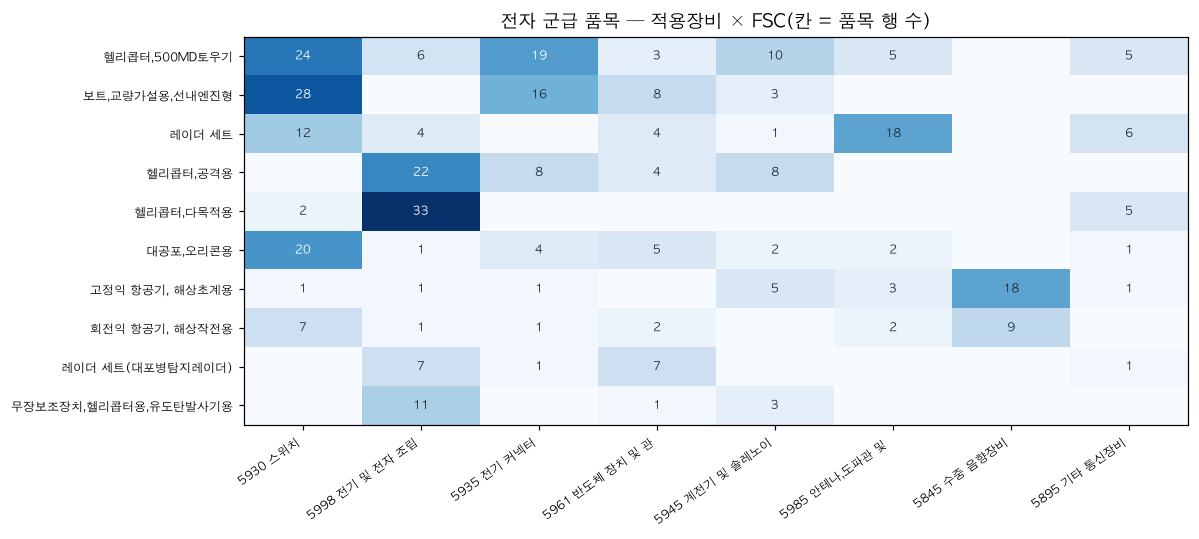

In [5]:
b4 = q("B4")
b4["fsc"] = b4.fsc4 + " " + b4.fsc_name.str.slice(0, 10)
pv = b4.pivot_table(index="equipment", columns="fsc", values="n", aggfunc="sum").fillna(0)
pv = pv.loc[pv.sum(axis=1).sort_values(ascending=False).index, pv.sum().sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(pv.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(pv.columns)), pv.columns, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(pv.index)), [s[:24] for s in pv.index], fontsize=8)
for i in range(pv.shape[0]):
    for j in range(pv.shape[1]):
        v = int(pv.values[i, j])
        if v: ax.text(j, i, v, ha="center", va="center", fontsize=8, color="white" if v > pv.values.max() * .55 else "#1d2b36")
ax.set_title("전자 군급 품목 — 적용장비 × FSC(칸 = 품목 행 수)")
plt.tight_layout(); plt.show()

## 5. 소요연도별 전자 군급 구성 [B5]

소요연도는 계약 · 납품 연도가 아니다. 2018~2020은 행이 거의 없어(0~2행) 그림에서 뺀다 — 자료 공백이지 소요가 없었다는 뜻이 아니다.

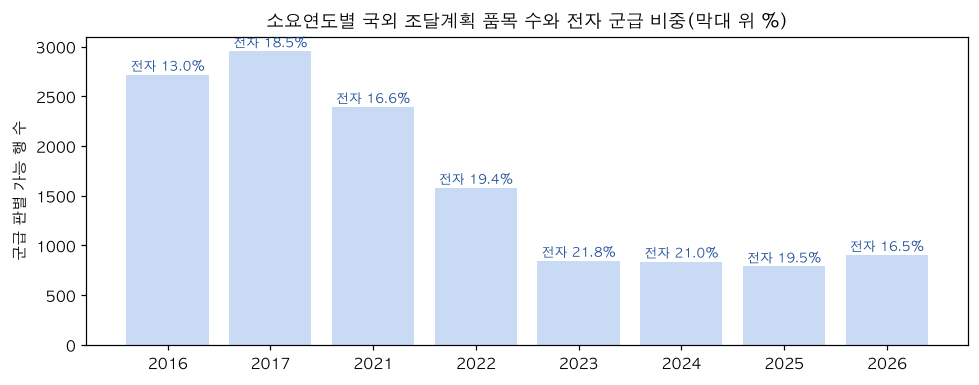

,demand_year,n_valid,fsg58,fsg59,fsg60,elec_pct
0,2016,2717.0,45.0,306.0,2.0,13.0
1,2017,2953.0,94.0,450.0,2.0,18.5
2,2018,1.0,1.0,0.0,0.0,100.0
3,2020,2.0,0.0,0.0,0.0,0.0
4,2021,2392.0,73.0,323.0,2.0,16.6
5,2022,1579.0,70.0,236.0,0.0,19.4
6,2023,845.0,41.0,141.0,2.0,21.8
7,2024,837.0,41.0,132.0,3.0,21.0
8,2025,788.0,45.0,109.0,0.0,19.5
9,2026,903.0,51.0,98.0,0.0,16.5


In [6]:
b5 = q("B5")
show = b5[b5.n_valid >= 100]
fig, ax1 = plt.subplots(figsize=(9, 3.6))
ax1.bar(show.demand_year.astype(int).astype(str), show.n_valid, color=BLUE4)
for x, (n, p) in enumerate(zip(show.n_valid, show.elec_pct)):
    ax1.text(x, n + 40, f"전자 {p:.1f}%", ha="center", fontsize=8.5, color=BLUE)
ax1.set(ylabel="군급 판별 가능 행 수", title="소요연도별 국외 조달계획 품목 수와 전자 군급 비중(막대 위 %)")
plt.tight_layout(); plt.show()
b5

## 6. 국외 조달계획 vs 국산화개발품목 — 전자 군급 구성 나란히 [B6]

두 자료는 모집 범위가 다르고 **결합하지 않는다.** 각 자료 **안의** 구성비만 나란히 놓는다. 국산화 쪽은 정제본 고유 행(뷰 `v_b2_fsg_summary.b2_row_count`는 중복 포함이라 쓰지 않음).

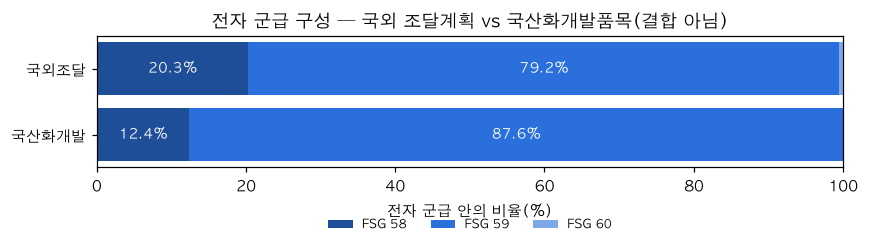

fsg,58,59,60,합계
src,,,,
국산화개발,337,2380,0,2717
국외조달,461,1795,11,2267


In [7]:
b6 = q("B6")
pv6 = b6.pivot_table(index="src", columns="fsg", values="n", aggfunc="sum").fillna(0)
share = pv6.div(pv6.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(8, 2.6))
left = np.zeros(len(share))
for col, color in zip(["58", "59", "60"], [BLUE, BLUE2, BLUE3]):
    if col in share:
        ax.barh(share.index, share[col], left=left, color=color, label=f"FSG {col}")
        for i, v in enumerate(share[col]):
            if v > 4: ax.text(left[i] + v / 2, i, f"{v:.1f}%", ha="center", va="center", color="white", fontsize=9)
        left += share[col].values
ax.set(xlim=(0, 100), xlabel="전자 군급 안의 비율(%)", title="전자 군급 구성 — 국외 조달계획 vs 국산화개발품목(결합 아님)")
ax.legend(ncol=3, frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.3))
plt.tight_layout(); plt.show()
pv6.assign(합계=pv6.sum(axis=1)).astype(int)

## 7. (부록) 국내 · 국외 조달계획 계약방법 구성 [B7]

부품과 연결 키가 없는 조달 자료라 본문 결론에 쓰지 않는다. 검정 없이 구성비만 — 국외에는 제도상 제한경쟁이 없다.

In [8]:
b7 = q("B7")
b7.pivot_table(index="contract_method", columns="src", values="pct", aggfunc="sum").fillna(0).sort_values("국내", ascending=False)

src,국내,국외
contract_method,,
수의계약,74.6,45.8
제한경쟁,12.5,0.0
일반경쟁,11.5,26.1
2단계경쟁(동시),0.7,27.4
협상에의한계약(전자),0.4,0.0
협상에의한계약(서류),0.2,0.1
지명경쟁,0.1,0.1
2단계경쟁(분리),0.0,0.6


## 8. 국방표준(KDSIS) 연결률 [B8]

국외 조달계획 재고번호가 국방표준 등록 NSN과 정확히 맞는 비율. 미연결은 채우지 않는다.

In [9]:
q("B8")

,kdsis_link_status,n,pct
0,미연결,12620,92.7
1,연결,616,4.5
2,대상아님,379,2.8


## 9. 요약 · 한계

### 발견 (모두 위 셀의 실행 결과, RDS 정제본)

| # | 구분 | 내용 |
|---|---|---|
| 1 | 단계 | 13,615 → 군급 판별 13,236 → 임시 번호 제외 **13,017**(분모) → 전자 군급 **2,267**(17.4%) |
| 2 | 군별 | 전자 군급 비중은 **해군 23.7% > 육군 13.7% > 공군 10.8% > 해병대 10.2%**. 해군은 58(통신 · 탐지) 비중도 가장 크다 |
| 3 | 적용장비 | 품목이 가장 많은 장비는 헬리콥터(500MD토우기) 1,833행이지만 전자 비율은 낮고, **레이더 세트는 129행 중 92행(71%)이 전자 군급** — 장비별 전자 비중이 크게 다르다 |
| 4 | 연도 | 전자 군급 비중은 13.0%(2016) → 21.8%(2023) → 16.5%(2026)로 오르내린다. 2018~2020은 자료 공백 |
| 5 | 두 자료 | 전자 군급 안에서 59(전기 · 전자 구성품)가 두 자료 모두 대부분 — 국외조달 79.2%, 국산화개발 87.6% |
| 6 | 연결 | 국방표준 NSN과 정확히 맞는 행은 4.5%(616행)뿐이다 — 품명 보강은 이 범위 안에서만 가능 |

### 한계 · 주의

- 공급 국가 · 통화가 없는 자료다. 공급국 추정 · 금액 합산을 하지 않는다.
- 소요연도는 계획 시점이며 계약 · 납품 시점이 아니다. 2018~2020 공백은 제공 자료의 공백이다.
- 적용장비명은 원문 기준(표준화 전). 같은 장비가 다른 이름으로 나뉘어 있을 수 있다.
- 관세청 HS 품목군과 결합하지 않는다. 국외조달의 「전자 군급」과 관세청의 「전자부품 품목군」은 다른 분류다.